In [1]:
#Import Necessary Libraries and Modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib
import calendar
from sklearn.cluster import KMeans
 

Loading the Dataset (Load dataset and inspect structure)
 

In [2]:
df=pd.read_csv("E-Commerce.csv")
df.head()

,CustomerID,Gender,InvoiceDate,InvoiceNumber,ProductID,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeviceCategory,Device,OS,DeliveryRating,ProductRating,Sales
0,9691,Female,1/01/2019,26088332,32,3,91.37,274.11,Completed,India,Social Media,6.54,Computer,Laptop,Windows,2,5,274.11
1,8327,Female,1/01/2019,95183269,34,1,48.24,48.24,In Process,India,Social Media,5.01,Computer,Desktop,Windows,0,0,0.00
2,6801,Male,1/01/2019,44769684,64,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,Computer,Desktop,Windows,1,2,70.46
3,4406,Male,1/02/2019,12422351,41,2,32.33,64.66,Completed,Philippines,Social Media,1.95,Mobile,Tablet,Windows,4,4,64.66
4,1966,Male,1/03/2019,84352310,20,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,Computer,Laptop,Windows,5,3,81.89


Explore and Clean the Dataset
 

In [3]:
df.describe()

,CustomerID,InvoiceNumber,ProductID,Quantity,Price,Total,SessionDuration,DeliveryRating,ProductRating,Sales
count,3599.000000,3.599000e+03,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000,3599.000000
mean,5526.962767,5.582117e+07,50.864962,2.000556,48.714571,97.394143,4.992101,2.641011,2.653515,61.185285
std,2586.425565,2.568169e+07,29.035862,0.813313,29.499165,74.421471,2.896605,2.181087,2.179732,75.880928
min,1111.000000,1.114055e+07,1.000000,1.000000,1.220000,1.220000,0.010000,0.000000,0.000000,0.000000
25%,3288.000000,3.355699e+07,26.000000,1.000000,26.030000,37.610000,2.490000,0.000000,0.000000,0.000000
50%,5546.000000,5.614293e+07,52.000000,2.000000,43.500000,81.460000,4.930000,3.000000,4.000000,31.260000
75%,7777.000000,7.810160e+07,76.000000,3.000000,74.550000,147.060000,7.515000,5.000000,5.000000,98.040000
max,9998.000000,9.996354e+07,100.000000,3.000000,99.720000,299.160000,10.000000,5.000000,5.000000,299.160000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3599 non-null   int64  
 1   Gender           3599 non-null   object 
 2   InvoiceDate      3599 non-null   object 
 3   InvoiceNumber    3599 non-null   int64  
 4   ProductID        3599 non-null   int64  
 5   Quantity         3599 non-null   int64  
 6   Price            3599 non-null   float64
 7   Total            3599 non-null   float64
 8   OrderStatus      3599 non-null   object 
 9   Country          3599 non-null   object 
 10  TrafficSource    3599 non-null   object 
 11  SessionDuration  3599 non-null   float64
 12  DeviceCategory   3599 non-null   object 
 13  Device           3599 non-null   object 
 14  OS               3599 non-null   object 
 15  DeliveryRating   3599 non-null   int64  
 16  ProductRating    3599 non-null   int64  
 17  Sales         

In [5]:
df.dtypes

CustomerID           int64
Gender              object
InvoiceDate         object
InvoiceNumber        int64
ProductID            int64
Quantity             int64
Price              float64
Total              float64
OrderStatus         object
Country             object
TrafficSource       object
SessionDuration    float64
DeviceCategory      object
Device              object
OS                  object
DeliveryRating       int64
ProductRating        int64
Sales              float64
dtype: object

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'InvoiceDate', 'InvoiceNumber', 'ProductID',
       'Quantity', 'Price', 'Total', 'OrderStatus', 'Country', 'TrafficSource',
       'SessionDuration', 'DeviceCategory', 'Device', 'OS', 'DeliveryRating',
       'ProductRating', 'Sales'],
      dtype='object')

In [7]:
df.shape

(3599, 18)

In [8]:
df.isnull()

,CustomerID,Gender,InvoiceDate,InvoiceNumber,ProductID,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeviceCategory,Device,OS,DeliveryRating,ProductRating,Sales
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3594,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3595,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3596,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3597,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().any()

CustomerID         False
Gender             False
InvoiceDate        False
InvoiceNumber      False
ProductID          False
Quantity           False
Price              False
Total              False
OrderStatus        False
Country            False
TrafficSource      False
SessionDuration    False
DeviceCategory     False
Device             False
OS                 False
DeliveryRating     False
ProductRating      False
Sales              False
dtype: bool

In [10]:
# Check for missing values in each column(no missing value)
df.isnull().sum()

CustomerID         0
Gender             0
InvoiceDate        0
InvoiceNumber      0
ProductID          0
Quantity           0
Price              0
Total              0
OrderStatus        0
Country            0
TrafficSource      0
SessionDuration    0
DeviceCategory     0
Device             0
OS                 0
DeliveryRating     0
ProductRating      0
Sales              0
dtype: int64

In [11]:
#changing invoice date from object to date time
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.head()

,CustomerID,Gender,InvoiceDate,InvoiceNumber,ProductID,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeviceCategory,Device,OS,DeliveryRating,ProductRating,Sales
0,9691,Female,2019-01-01,26088332,32,3,91.37,274.11,Completed,India,Social Media,6.54,Computer,Laptop,Windows,2,5,274.11
1,8327,Female,2019-01-01,95183269,34,1,48.24,48.24,In Process,India,Social Media,5.01,Computer,Desktop,Windows,0,0,0.00
2,6801,Male,2019-01-01,44769684,64,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,Computer,Desktop,Windows,1,2,70.46
3,4406,Male,2019-01-02,12422351,41,2,32.33,64.66,Completed,Philippines,Social Media,1.95,Mobile,Tablet,Windows,4,4,64.66
4,1966,Male,2019-01-03,84352310,20,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,Computer,Laptop,Windows,5,3,81.89


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       3599 non-null   int64         
 1   Gender           3599 non-null   object        
 2   InvoiceDate      3599 non-null   datetime64[ns]
 3   InvoiceNumber    3599 non-null   int64         
 4   ProductID        3599 non-null   int64         
 5   Quantity         3599 non-null   int64         
 6   Price            3599 non-null   float64       
 7   Total            3599 non-null   float64       
 8   OrderStatus      3599 non-null   object        
 9   Country          3599 non-null   object        
 10  TrafficSource    3599 non-null   object        
 11  SessionDuration  3599 non-null   float64       
 12  DeviceCategory   3599 non-null   object        
 13  Device           3599 non-null   object        
 14  OS               3599 non-null   object 

Calculating Recency(how recently a customer made a purchase by grouping the data by CustomerID )

In [14]:
df_recency = df.groupby(by='CustomerID', as_index=False)['InvoiceDate'].max()
df_recency.columns = ['CustomerID', 'LastInvoiceDate']
recent_date = df_recency['LastInvoiceDate'].max()
df_recency['Recency'] = df_recency['LastInvoiceDate'].apply(lambda x: (recent_date - x).days)
df_recency.head()

,CustomerID,LastInvoiceDate,Recency
0,1111,2022-09-15,472
1,1114,2023-06-02,212
2,1118,2023-09-03,119
3,1119,2023-05-28,217
4,1122,2023-10-08,84


calculating Frequency(how recently a customer made a purchase by grouping the data by CustomerID )

In [15]:
frequency_df = df.drop_duplicates().groupby(by=['CustomerID'], as_index=False)['InvoiceDate'].count()
frequency_df.columns = ['CustomerID', 'Frequency']
frequency_df.head()

,CustomerID,Frequency
0,1111,1
1,1114,1
2,1118,2
3,1119,1
4,1122,1


Calculate Monetary Value(how much a customer spends by price )

In [16]:
df['Total'] = df['Price']  # Total spent by each customer
monetary_df = df.groupby(by='CustomerID', as_index=False)['Total'].sum()
monetary_df.columns = ['CustomerID', 'Monetary']
monetary_df.head()

,CustomerID,Monetary
0,1111,52.78
1,1114,87.34
2,1118,119.31
3,1119,72.93
4,1122,78.78


Merging Recency, Frequency and Monetary Data(This will give a comprehensive view of the customer’s behavior.)

In [18]:
rf_df = df_recency.merge(frequency_df, on='CustomerID')
rfm_df = rf_df.merge(monetary_df, on='CustomerID').drop(columns='LastInvoiceDate')
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,1111,472,1,52.78
1,1114,212,1,87.34
2,1118,119,2,119.31
3,1119,217,1,72.93
4,1122,84,1,78.78


Ranking Customers Based on Recency, Frequency and Monetary
(For recency, a lower value means the customer purchased a long time ago 
 On the other hand, higher frequency and higher monetary values indicate more loyal 
 and high-value customers.                                                         )

In [23]:
rfm_df['R_rnk'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rnk'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rnk'] = rfm_df['Monetary'].rank(ascending=True)

Normalizing the Ranks  to a scale of 0-100 to make them easier to compare. 

In [24]:
rfm_df['R_rank_norm'] = (rfm_df['R_rnk'] / rfm_df['R_rnk'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rnk'] / rfm_df['F_rnk'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rnk'] / rfm_df['M_rnk'].max()) * 100

In [25]:
rfm_df.drop(columns=['R_rnk', 'F_rnk', 'M_rnk'], inplace=True)
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,R_rk,F_rk,M_rk,R_rank_norm,F_rank_norm,M_rank_norm
0,1111,472,1,52.78,2060.5,1207.5,1456.0,2060.5,1207.5,1456.0,69.611486,40.862944,49.172577
1,1114,212,1,87.34,2546.5,1207.5,2293.5,2546.5,1207.5,2293.5,86.030405,40.862944,77.456940
2,1118,119,2,119.31,2720.5,2649.0,2743.0,2720.5,2649.0,2743.0,91.908784,89.644670,92.637622
3,1119,217,1,72.93,2535.5,1207.5,1904.0,2535.5,1207.5,1904.0,85.658784,40.862944,64.302600
4,1122,84,1,78.78,2795.5,1207.5,2083.5,2795.5,1207.5,2083.5,94.442568,40.862944,70.364742


Calculating RFM Score

In [26]:
rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] + 0.28 * rfm_df['F_rank_norm'] + 0.57 * rfm_df['M_rank_norm']
rfm_df['RFM_Score'] *= 0.05
rfm_df = rfm_df.round(2)

Display RFM Score and CustomerID(for the first few customers)

In [27]:
rfm_df[['CustomerID', 'RFM_Score']].head(10)

,CustomerID,RFM_Score
0,1111,2.50
1,1114,3.42
2,1118,4.58
3,1119,3.05
4,1122,3.29
5,1123,1.47
6,1128,2.77
7,1129,1.22
8,1130,4.13
9,1132,2.23


Segmenting Customers Based on RFM Score(This helps to categorize them into groups like Top Customers,
High Value Customers, etc.)

In [28]:
rfm_df["Customer_segment"] = np.where(rfm_df['RFM_Score'] > 4.5, "Top Customers",
                                       np.where(rfm_df['RFM_Score'] > 4, "High value Customer",
                                                np.where(rfm_df['RFM_Score'] > 3, "Medium Value Customer",
                                                         np.where(rfm_df['RFM_Score'] > 1.6, 'Low Value Customers', 'Lost Customers'))))

the first 15 rows with CustomerID, RFM_Score and Customer_segment to see how customers have been grouped.

In [30]:
rfm_df[['CustomerID', 'RFM_Score', 'Customer_segment']].head(15)

,CustomerID,RFM_Score,Customer_segment
0,1111,2.50,Low Value Customers
1,1114,3.42,Medium Value Customer
2,1118,4.58,Top Customers
3,1119,3.05,Medium Value Customer
4,1122,3.29,Medium Value Customer
5,1123,1.47,Lost Customers
6,1128,2.77,Low Value Customers
7,1129,1.22,Lost Customers
8,1130,4.13,High value Customer
9,1132,2.23,Low Value Customers


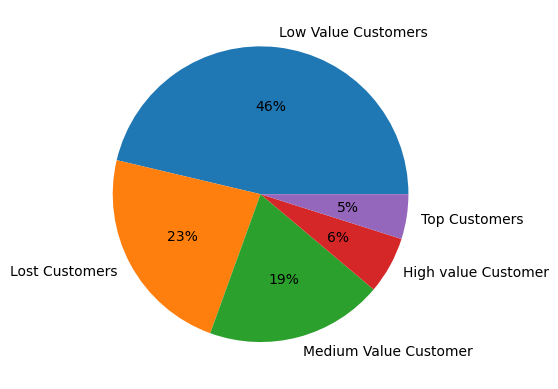

In [31]:
plt.pie(rfm_df.Customer_segment.value_counts(),
        labels=rfm_df.Customer_segment.value_counts().index,
        autopct='%.0f%%')
plt.show()

Descriptive statistics: average purchase value, purchase frequency, customer lifetime value

In [32]:
snapshot_date = max(df['InvoiceDate']) + pd.DateOffset(days=1)
snapshot_date

Timestamp('2024-01-01 00:00:00')

 Map RFM Values
 

<Axes: >

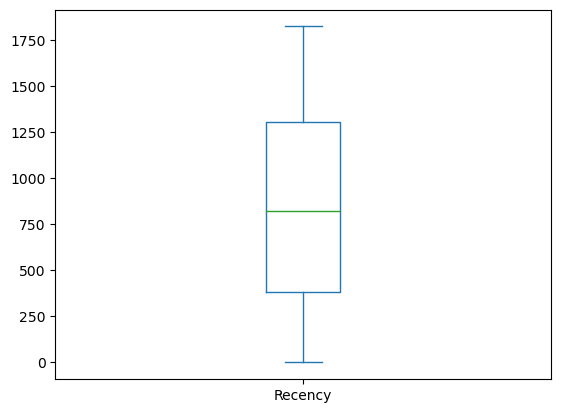

In [34]:
rfm_df['Recency'].plot(kind='box')

Mapping RFM Values

In [36]:
rfm_df.describe()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,R_rk,F_rk,M_rk,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
count,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000,2961.000000
mean,5511.194867,851.790949,1.215468,59.210990,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,50.033860,50.115299,50.016606,2.502398
std,2583.105646,529.569143,0.489253,41.102083,854.911165,576.126423,854.885736,854.911165,576.126423,854.885736,28.882039,19.496293,28.871822,1.034257
min,1111.000000,0.000000,1.000000,1.220000,2.000000,1207.500000,9.000000,2.000000,1207.500000,9.000000,0.070000,40.860000,0.300000,0.600000
25%,3277.000000,384.000000,1.000000,31.260000,740.500000,1207.500000,737.000000,740.500000,1207.500000,737.000000,25.020000,40.860000,24.890000,1.650000
50%,5507.000000,823.000000,1.000000,52.960000,1481.500000,1207.500000,1480.000000,1481.500000,1207.500000,1480.000000,50.050000,40.860000,49.980000,2.410000
75%,7744.000000,1306.000000,1.000000,85.040000,2220.000000,1207.500000,2228.500000,2220.000000,1207.500000,2228.500000,75.000000,40.860000,75.260000,3.170000
max,9998.000000,1825.000000,4.000000,298.790000,2960.000000,2955.000000,2961.000000,2960.000000,2955.000000,2961.000000,100.000000,100.000000,100.000000,4.980000


Performing K-Means Clustering
 

In [37]:
# Extract RFM scores for K-means clustering
X = rfm_df[['R_score', 'F_score', 'M_score']]

In [39]:
# Calculating inertia (sum of squared distances) for different values of k(we need to find the optimal number of clusters.)
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init= 10, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

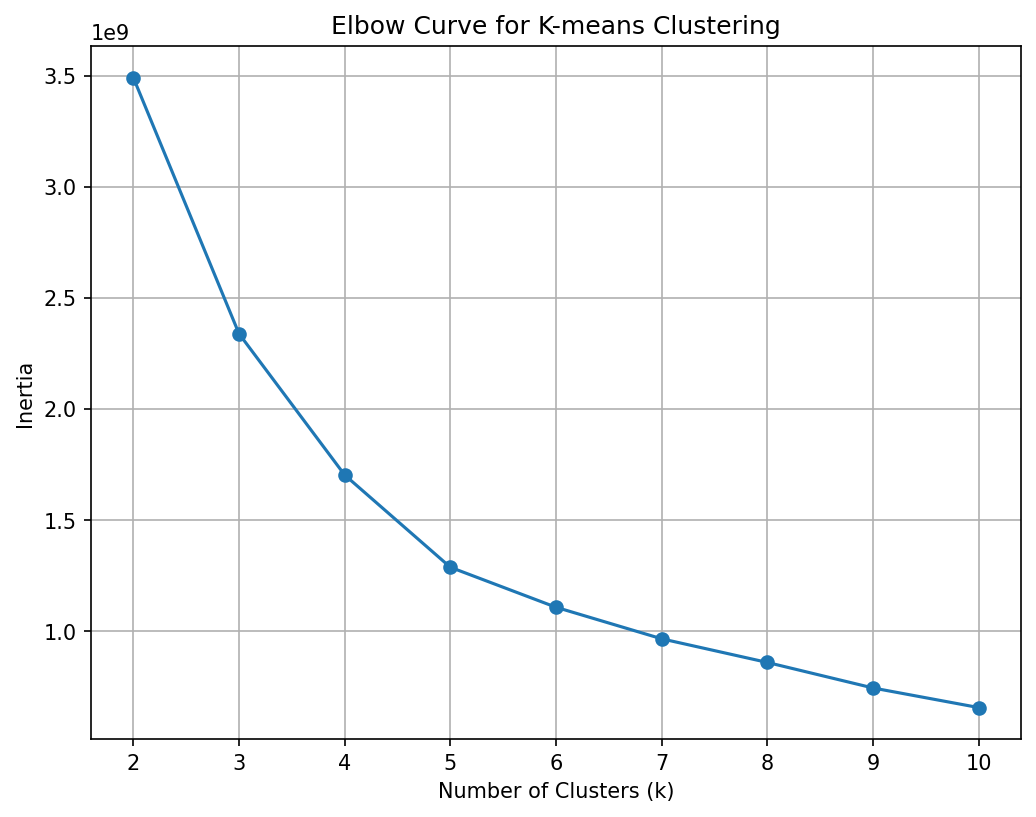

In [40]:
# Ploting the elbow curve( the curve elbows out at 4 clusters.)
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

In [42]:
# Performing K-means clustering with best K( we need run the K-Means algorithm to get the cluster assignments 
#for all points in the dataset:)
best_kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
rfm_df['Cluster'] = best_kmeans.fit_predict(X)

In [46]:
# Group by cluster and calculate mean values( by characterize them based on the RFM scores.)
cluster_summary = rfm_df.groupby('Cluster').agg({
    'R_score': 'mean',
    'F_score': 'mean',
    'M_score': 'mean'
}).reset_index()

In [47]:
print(cluster_summary)

   Cluster      R_score      F_score      M_score
0        0   829.800126  1240.220050   627.817150
1        1   845.164122  1260.685115  2055.222010
2        2  2310.308333  1236.330000  1220.691667
3        3  2040.732365  2693.259336  2434.346473


visualizing the average R, F, and M scores for the clusters so that it can be easy to interpret:

In [48]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

In [49]:
# Plotting the average RFM scores for each cluster
plt.figure(figsize=(10, 8),dpi=150)

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

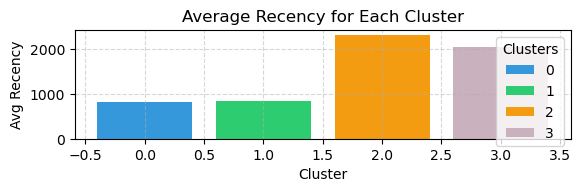

In [50]:
# Plot Avg Recency
plt.subplot(3, 1, 1)
bars = plt.bar(cluster_summary.index, cluster_summary['R_score'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

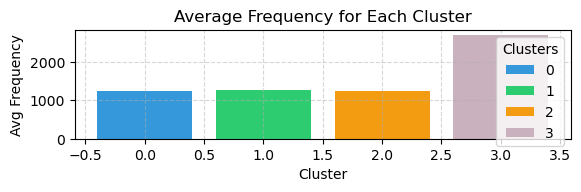

In [51]:
# Plot Avg Frequency
plt.subplot(3, 1, 2)
bars = plt.bar(cluster_summary.index, cluster_summary['F_score'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

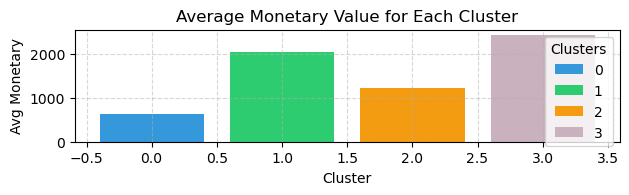

In [52]:
# Plot Avg Monetary
plt.subplot(3, 1, 3)
bars = plt.bar(cluster_summary.index, cluster_summary['M_score'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

plt.tight_layout()
plt.show()

In [54]:
cluster_counts = rfm_df['Cluster'].value_counts()

colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

In [56]:
# Calculate the total number of customers
total_customers = cluster_counts.sum()

In [64]:
# Calculate the percentage of customers in each cluster
percentage_customers = (cluster_counts / total_customers) * 100

labels = ['High value Customer','Top Customers','Medium Value Customer','Low Value Customers']

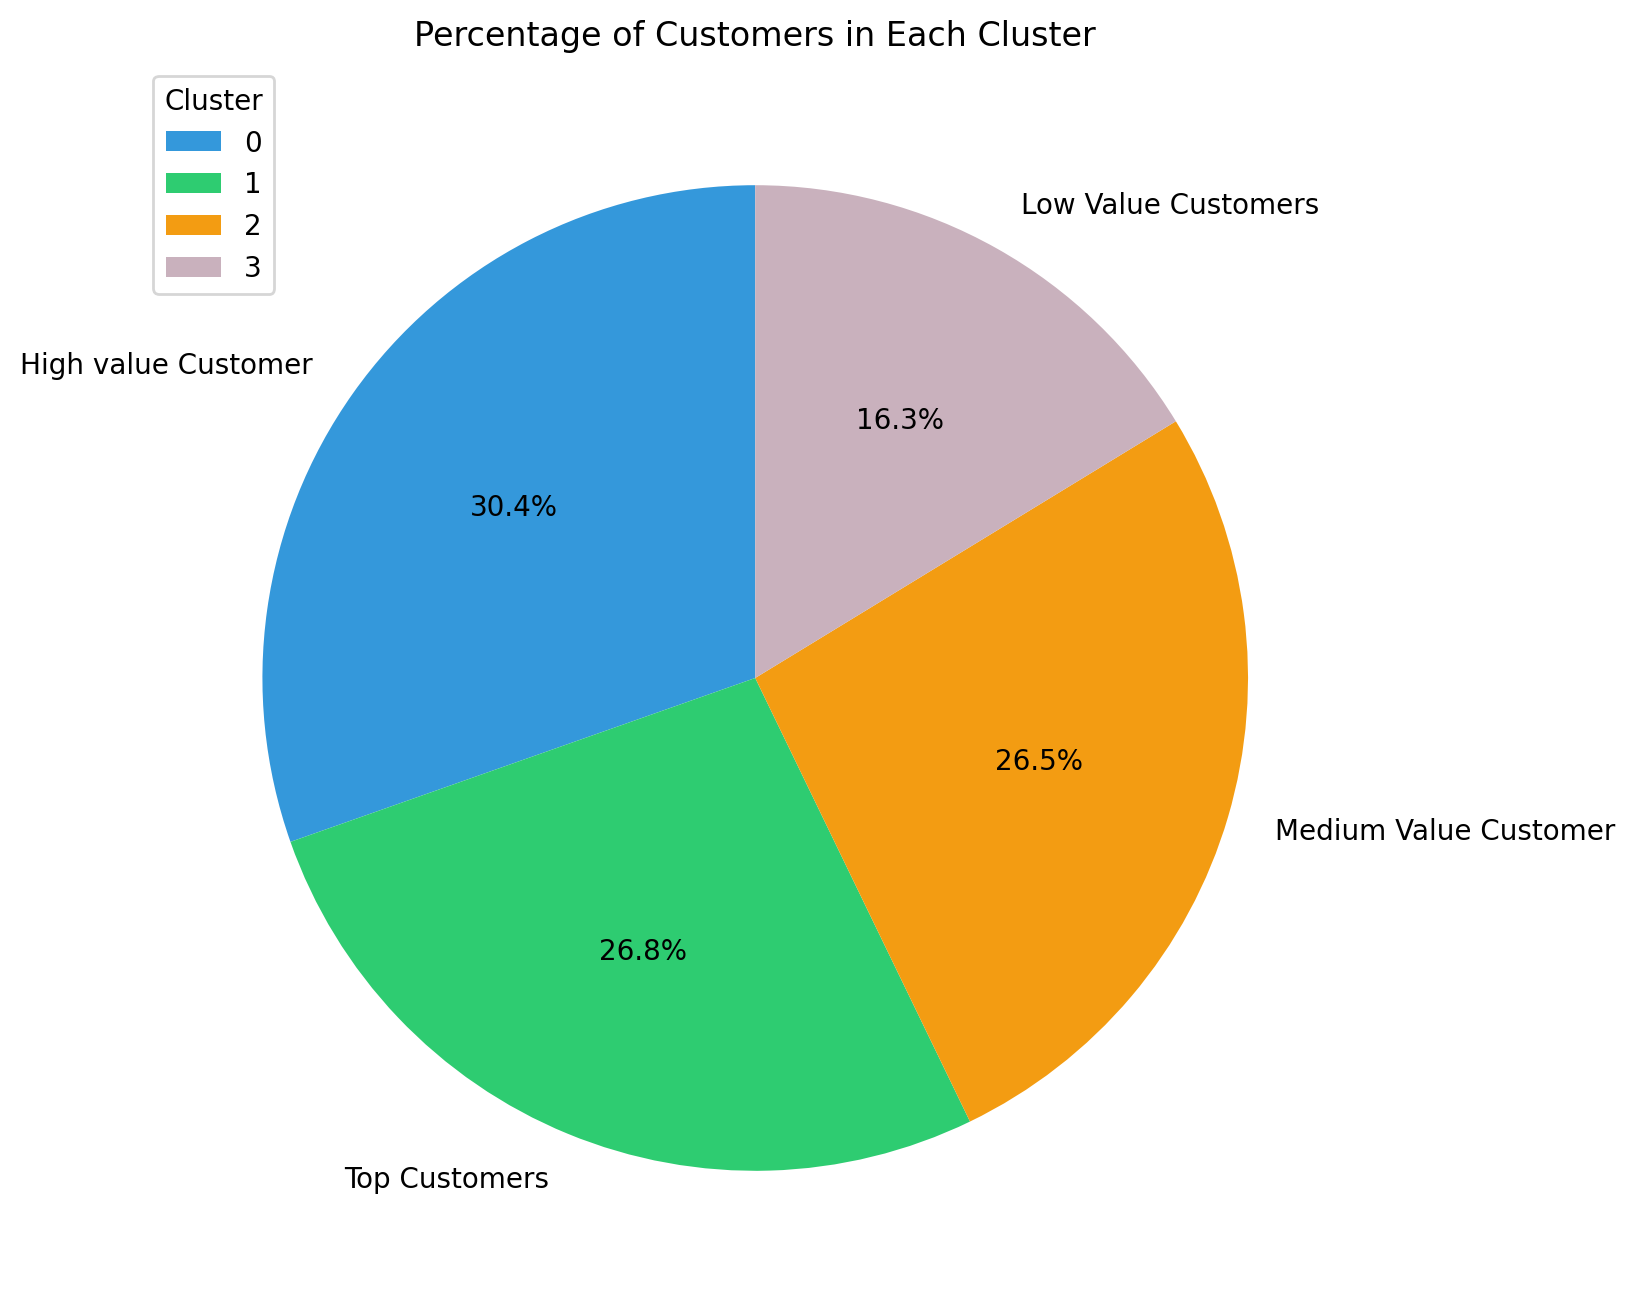

In [65]:
# Create a pie chart
plt.figure(figsize=(8, 8),dpi=200)
plt.pie(percentage_customers, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage of Customers in Each Cluster')
plt.legend(cluster_summary['Cluster'], title='Cluster', loc='upper left')

plt.show()

In [ ]:
#Insights recommendation for each segment?
#By identifying high-value customer and low value customers,businesses can allocate resources more efficiently,and 
#focusing efforts where they are most likely to yield results.

#All the segment helps businesses create strategies by understanding what keeps customers engaged and satisfied.
#Business can gain insights of customer behaviour and can plan accordingly.